In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [14]:
df = pd.read_csv("Student_Performance.csv")

In [15]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23
9996,7,64,Yes,8,5,58
9997,6,83,Yes,8,5,74
9998,9,97,Yes,7,0,95


In [16]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

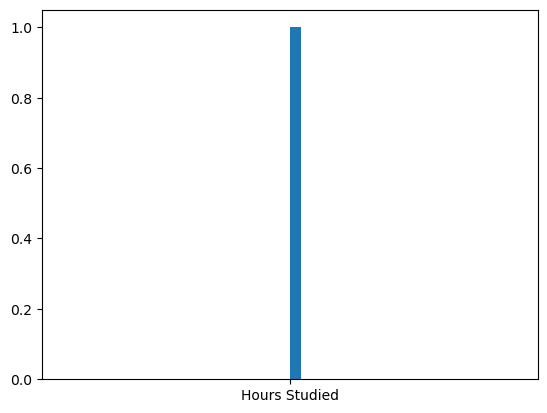

In [17]:
plt.hist(x='Hours Studied',bins=40)
plt.show()

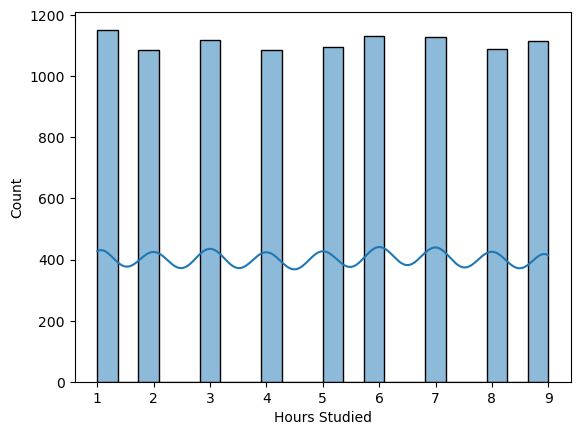

In [7]:
sns.histplot(x='Hours Studied',data=df,kde=True)
plt.show()

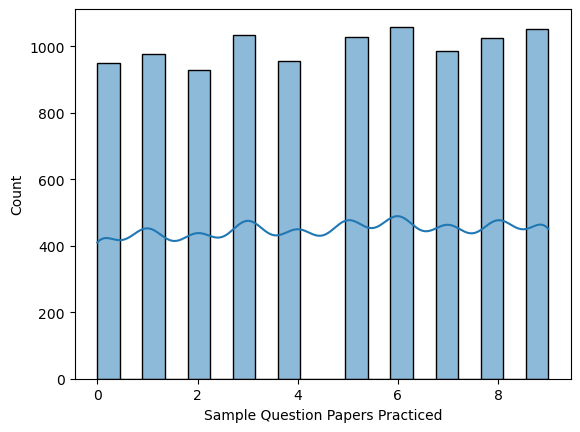

In [8]:
sns.histplot(x='Sample Question Papers Practiced',data=df,kde=True)
plt.show()

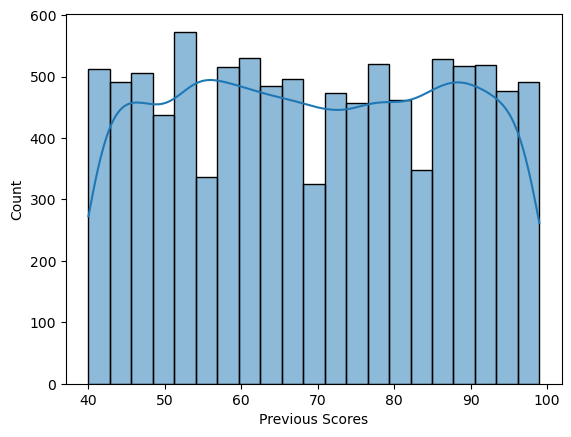

In [9]:
sns.histplot(x='Previous Scores',data=df,kde=True)
plt.show()

In [18]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [19]:
## Onehot Encoding for Extracurricular Activities
df = pd.get_dummies(df, columns=['Extracurricular Activities'],dtype=int,drop_first=True)

In [20]:
df

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91,1
1,4,82,4,2,65,0
2,8,51,7,2,45,1
3,5,52,5,2,36,1
4,7,75,8,5,66,0
...,...,...,...,...,...,...
9995,1,49,4,2,23,1
9996,7,64,8,5,58,1
9997,6,83,8,5,74,1
9998,9,97,7,0,95,1


In [21]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index',
       'Extracurricular Activities_Yes'],
      dtype='object')

In [22]:
df.corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730,0.003873
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189,0.008369
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106,-0.023284
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268,0.013103
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000,0.024525
Extracurricular Activities_Yes,0.003873,0.008369,-0.023284,0.013103,0.024525,1.000000


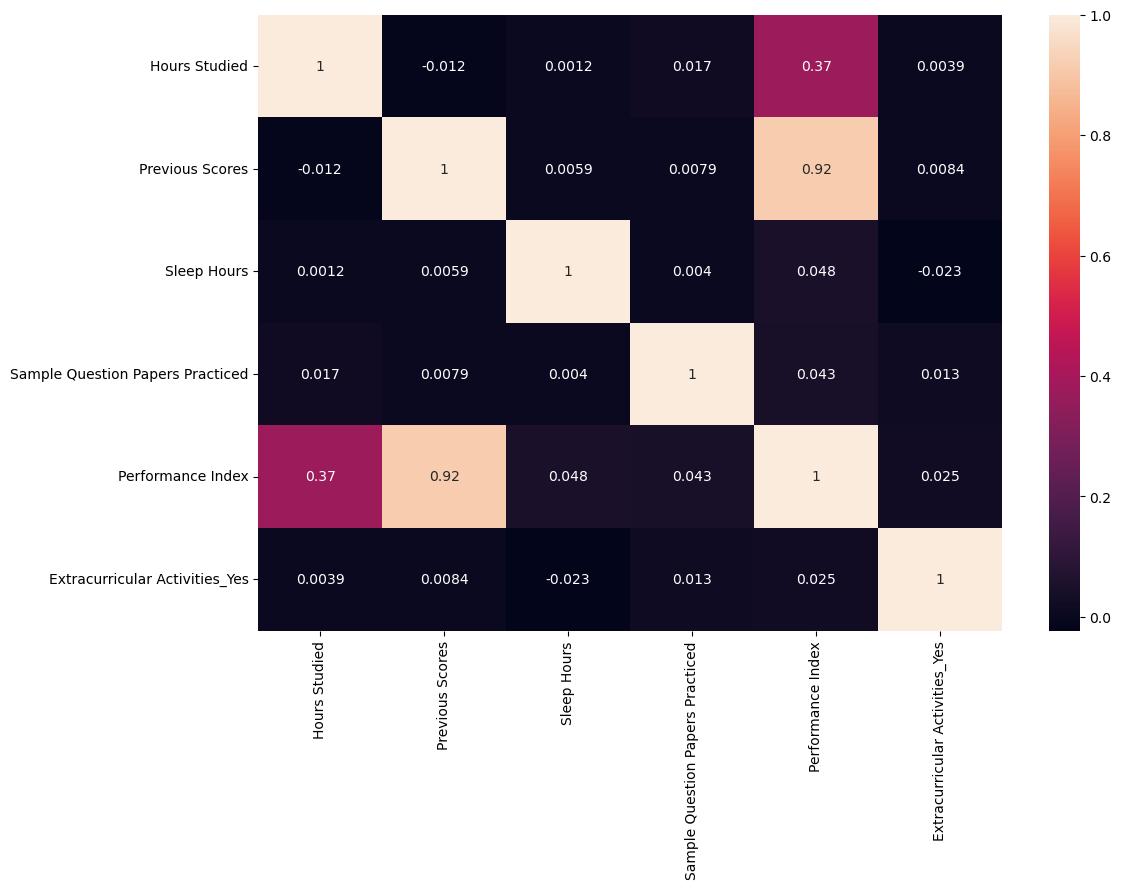

In [23]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

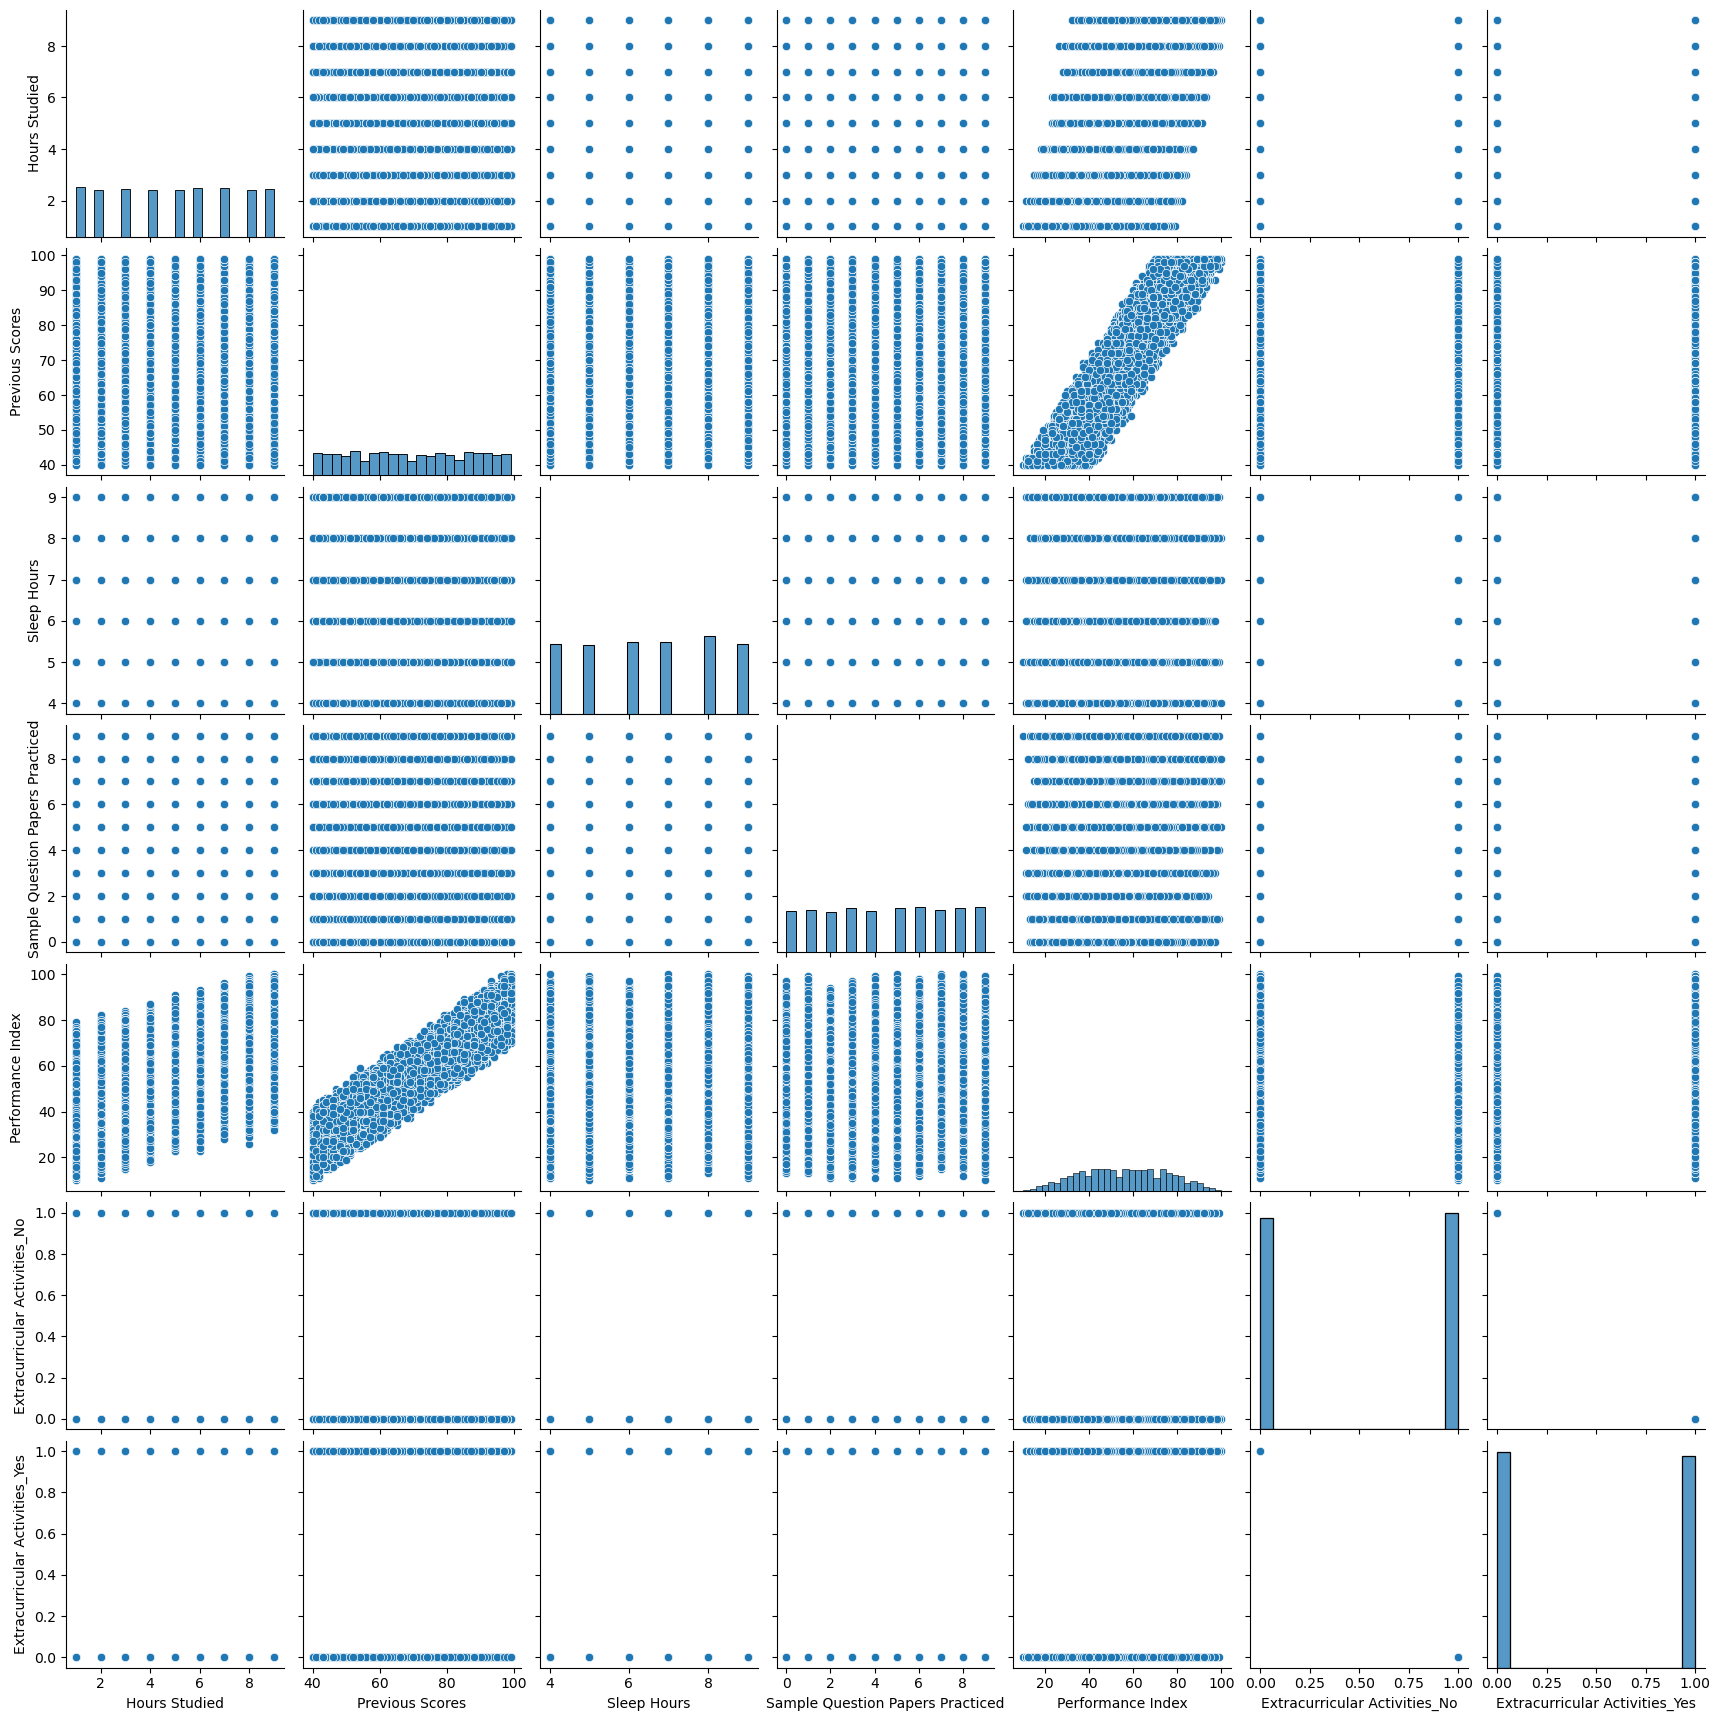

In [14]:
sns.pairplot(df)
plt.show()

In [24]:
col = df.pop("Performance Index")

In [25]:
col

0       91
1       65
2       45
3       36
4       66
        ..
9995    23
9996    58
9997    74
9998    95
9999    64
Name: Performance Index, Length: 10000, dtype: int64

In [26]:
df["Performance Index"] = col

In [27]:
df

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_Yes,Performance Index
0,7,99,9,1,1,91
1,4,82,4,2,0,65
2,8,51,7,2,1,45
3,5,52,5,2,1,36
4,7,75,8,5,0,66
...,...,...,...,...,...,...
9995,1,49,4,2,1,23
9996,7,64,8,5,1,58
9997,6,83,8,5,1,74
9998,9,97,7,0,1,95


In [28]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [29]:
X

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_Yes
0,7,99,9,1,1
1,4,82,4,2,0
2,8,51,7,2,1
3,5,52,5,2,1
4,7,75,8,5,0
...,...,...,...,...,...
9995,1,49,4,2,1
9996,7,64,8,5,1
9997,6,83,8,5,1
9998,9,97,7,0,1


In [30]:
y

0       91
1       65
2       45
3       36
4       66
        ..
9995    23
9996    58
9997    74
9998    95
9999    64
Name: Performance Index, Length: 10000, dtype: int64

In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

In [33]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6700, 5), (3300, 5), (6700,), (3300,))

In [34]:
from sklearn.preprocessing import StandardScaler

In [35]:
scaler = StandardScaler()

In [36]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
X_train

array([[-0.76523602,  0.65779988,  0.8591585 ,  0.13189775,  1.02233901],
       [-1.53501027,  1.06172795,  0.8591585 , -0.21698299,  1.02233901],
       [ 0.00453822, -0.90020839,  0.27051325, -0.91474445,  1.02233901],
       ...,
       [ 1.54408671, -1.24643245,  0.27051325,  0.48077848, -0.97814912],
       [-1.53501027, -1.30413646,  1.44780376, -1.61250591, -0.97814912],
       [-1.15012315, -1.36184047, -0.31813201,  0.48077848, -0.97814912]])

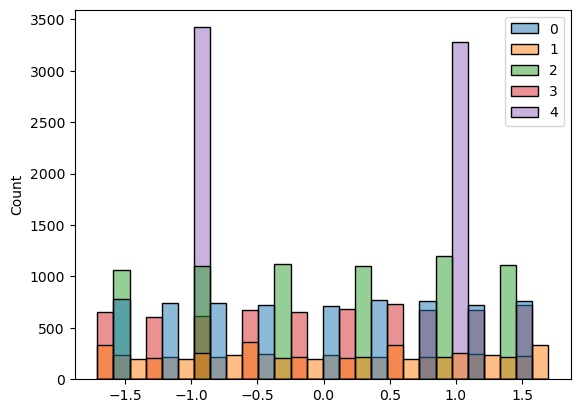

In [38]:
sns.histplot(X_train)
plt.show()

## Linear Regression

In [39]:
from sklearn.linear_model import LinearRegression

In [40]:
lin_reg = LinearRegression()

In [41]:
lin_reg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
lin_reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
lin_reg.coef_

array([ 7.42463143, 17.59967451,  0.81391366,  0.53092099,  0.29139082])

In [45]:
lin_reg.intercept_

55.401044776119406

In [46]:
y_pred = lin_reg.predict(X_test)

In [47]:
y_pred

array([54.75354173, 22.60032219, 47.92590021, ..., 43.12654287,
       71.56089039, 43.10599732])

In [48]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [49]:
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.073002572635983
1.609020558143057
2.018168122985789


In [50]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score*100)

adjusted_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(adjusted_r2*100)

98.9010089843778
98.89934081343728


In [77]:
X_train.shape

(6700, 5)

### Ridge Regression 

In [51]:
from sklearn.linear_model import Ridge

In [52]:
ridge = Ridge()

In [53]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [54]:
ridge.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [55]:
ridge.coef_

array([ 7.42349976, 17.59703848,  0.81381082,  0.5308895 ,  0.29136156])

In [56]:
ridge.intercept_

55.401044776119406

In [57]:
y_pred = ridge.predict(X_test)

In [58]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

4.073741017514862
1.6091490144369696
2.0183510639913123


In [59]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score*100)

adjusted_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(adjusted_r2*100)

98.90080973473998
98.89914126135616


### Lasso Regression 

In [60]:
from sklearn.linear_model import Lasso

In [61]:
lasso = Lasso()

In [62]:
lasso.fit(X_train,y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [63]:
y_pred = lasso.predict(X_test)

In [64]:
y_pred

array([54.85495545, 25.39887711, 47.34770651, ..., 43.91598655,
       70.82749925, 45.11737777])

In [65]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(np.sqrt(mean_squared_error(y_test,y_pred)))

7.444871473233449
2.1568087389578516
2.7285291776401164


In [66]:
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score*100)

adjusted_r2 = 1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(adjusted_r2*100)

97.99120017342626
97.98815099336164


In [68]:
val = scaler.transform([[8,70,8,3,0]])

c:\Users\hp\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [69]:
val

array([[ 1.15919959,  0.02305577,  0.8591585 , -0.56586372, -0.97814912]])

In [70]:
ridge.predict(val)

array([64.52586217])

In [71]:
import sklearn
sklearn.__version__

'1.7.1'

In [84]:
import pickle

pickle.dump(scaler, open("scaler.pkl", 'wb'))
pickle.dump(ridge, open("ridge.pkl", 'wb'))

In [82]:
m = pickle.load(open("ridge.pkl","rb"))

In [83]:
m.predict(val)

array([64.52586217])